# ML-testbed 06 — a differentiable machine and liner

We replace a prescribed motion trace with a coupled circuit and moving load. PyTorch now differentiates through a numerical solver. That makes the simulator useful for parameter fitting and later for training a world model.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** coupled ODEs, RK4 integration, autograd through time, finite-difference checks, conservation accounting

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. Read the reduced equations
The state is capacitor voltage $V$, current $I$, radius $r$, inward speed $u$, thermal proxy $T$, and generic perturbation amplitude $a$.

$$L(r)=L_0+k\log(1/r),\quad \dot L=ku/r,$$
$$\dot V=-I/C,\quad \dot I=(V-RI-I\dot L)/L,$$
$$\dot r=-u,\quad m\dot u=kI^2/(2r)-du,$$
$$\dot T=RI^2-\ell(T-0.1),\quad \dot a=(gI^2-0.2)a.$$

All quantities and constants are dimensionless. The same inductance coupling appears in circuit and force, which lets us check an energy balance. The heat variable has an arbitrary unit heat capacity. The growth law is deliberately generic: it is not an ETI or MRTI dispersion relation. We stop before convergence becomes singular.

In [2]:
import inspect
print(inspect.getsource(rhs))

def rhs(y, theta, cfg):
    """Batched differentiable circuit, motion, heat proxy and generic growth ODE."""
    v, current, radius, speed, heat, amp = y.unbind(-1)
    _, mass, resistance, growth = theta.unbind(-1)
    r = radius.clamp_min(.2)  # guard only; simulate() rejects trajectories reaching it
    inductance = cfg.inductance + cfg.coupling * torch.log(1 / r)
    ldot = cfg.coupling * speed / r
    # F = (I^2 / 2) dL/dx. The same coupling appears in the circuit and mechanics.
    accel = (.5 * cfg.coupling * current.square() / r - cfg.damping * speed) / mass
    return torch.stack((-current / cfg.capacitance,
        (v - resistance * current - current * ldot) / inductance,
        -speed, accel,
        resistance * current.square() - cfg.thermal_loss * (heat - .1),
        (growth * current.square() - .2) * amp), -1)



### Visual lab — The circuit pushes the liner—and the liner changes the circuit

The top path drives motion. The return arrow is feedback: changing radius changes inductance, which changes the current equation. The heat and perturbation variables are passive outputs of this particular model.

**Notice:** removing the motional-inductance term breaks the energy accounting, even if a trajectory still looks smooth.

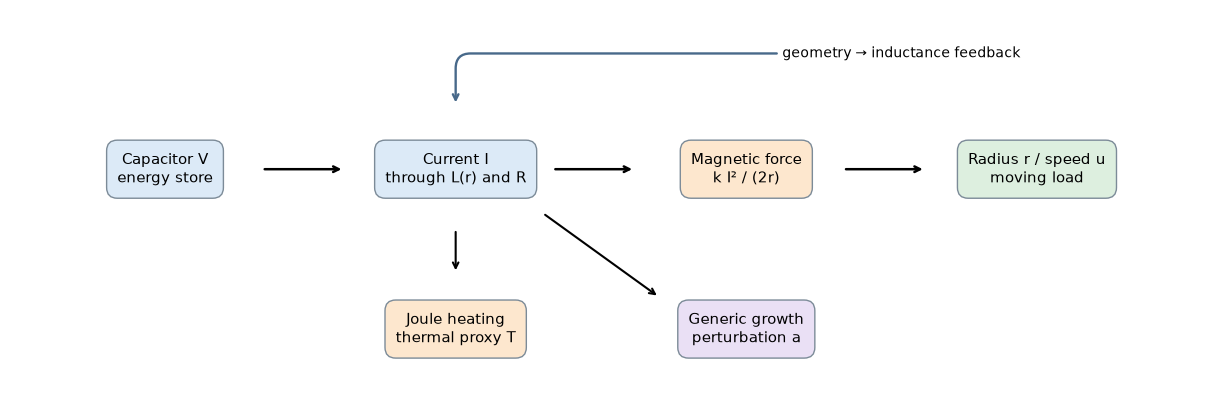

In [3]:
v_fig,v_ax=plt.subplots(figsize=(12,4),layout='constrained'); v_ax.axis('off')
for v_x,v_y,v_label,v_color in [(0,1,'Capacitor V\nenergy store','#dceaf7'),(3,1,'Current I\nthrough L(r) and R','#dceaf7'),(6,1,'Magnetic force\nk I² / (2r)','#fde7ce'),(9,1,'Radius r / speed u\nmoving load','#ddefdf'),(3,-1,'Joule heating\nthermal proxy T','#fde7ce'),(6,-1,'Generic growth\nperturbation a','#eae0f5')]:
    v_ax.text(v_x,v_y,v_label,ha='center',va='center',fontsize=11,bbox=dict(boxstyle='round,pad=.7',fc=v_color,ec='#7c8b98'))
for v_x in [0,3,6]: v_ax.annotate('',xy=(v_x+1.85,1),xytext=(v_x+1,1),arrowprops=dict(arrowstyle='->',lw=1.8))
v_ax.annotate('',xy=(3,.25),xytext=(3,-.3),arrowprops=dict(arrowstyle='<-',lw=1.5))
v_ax.annotate('',xy=(5.1,-.6),xytext=(3.9,.45),arrowprops=dict(arrowstyle='->',lw=1.5))
v_ax.annotate('geometry → inductance feedback',xy=(3,1.8),xytext=(7.6,2.4),ha='center',fontsize=10,
              arrowprops=dict(arrowstyle='->',connectionstyle='angle,angleA=0,angleB=90,rad=15',lw=1.7,color='#48698a'))
v_ax.set(xlim=(-1.6,10.7),ylim=(-1.9,3)); plt.show()

## 2. Integrate multiple configurations together
`simulate` uses explicit fourth-order Runge–Kutta. There is no neural network yet: gradients arise because the numerical arithmetic is written in PyTorch. Charge sets the initial capacitor voltage; it is not a facility charging prescription.

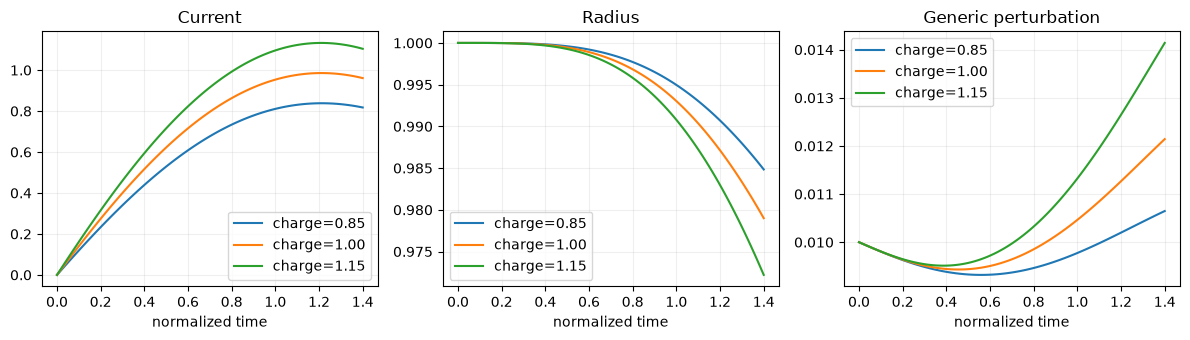

In [4]:
theta=torch.tensor([[.85,1.,.22,.6],[1.,1.,.22,.6],[1.15,1.,.22,.6]])
t,state=simulate(theta)
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for j,param in enumerate(theta):
    for ax,col in zip(axes,[1,2,5]): ax.plot(t,state[j,:,col],label=f'charge={param[0]:.2f}')
for ax,title in zip(axes,['Current','Radius','Generic perturbation']): ax.set(title=title,xlabel='normalized time'); ax.legend()
plt.tight_layout(); plt.show()

### Visual lab — Play a synthetic shot

Use the play/pause and frame controls under the animation. The same clock advances the current, radius and end-on liner sketch. The sketch uses the actual radius; the small radius change is easier to see in the middle panel. It is schematic geometry, not a mesh-based liner calculation.

**Predict:** does the minimum capacitor voltage coincide with the maximum inward speed? The existing state plots can help you check.

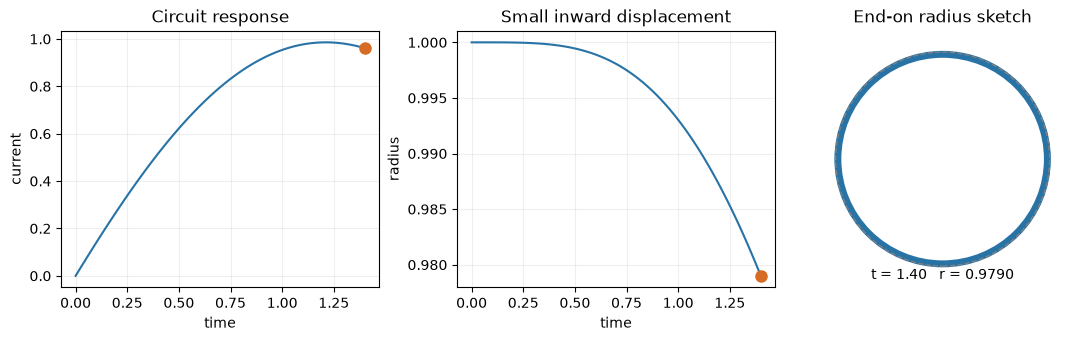

In [5]:
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
from IPython.display import HTML
v_t=t.detach().numpy(); v_shot=state[1].detach().numpy()
v_fig,v_axes=plt.subplots(1,3,figsize=(11,3.3),layout='constrained')
v_axes[0].plot(v_t,v_shot[:,1],color='#2873a6'); v_dot_i,=v_axes[0].plot([],[],'o',color='#d66b24',ms=8)
v_axes[0].set(xlabel='time',ylabel='current',title='Circuit response')
v_axes[1].plot(v_t,v_shot[:,2],color='#2873a6'); v_dot_r,=v_axes[1].plot([],[],'o',color='#d66b24',ms=8)
v_axes[1].set(xlabel='time',ylabel='radius',title='Small inward displacement')
v_ring=Circle((0,0),1,fill=False,lw=5,color='#2873a6'); v_axes[2].add_patch(v_ring)
v_axes[2].add_patch(Circle((0,0),1,fill=False,lw=1,ls='--',color='gray'))
v_axes[2].set(xlim=(-1.2,1.2),ylim=(-1.2,1.2),aspect='equal',title='End-on radius sketch'); v_axes[2].axis('off')
v_clock=v_axes[2].text(0,-1.12,'',ha='center',fontsize=10)
def v_update_shot(v_frame):
    v_dot_i.set_data([v_t[v_frame]],[v_shot[v_frame,1]])
    v_dot_r.set_data([v_t[v_frame]],[v_shot[v_frame,2]])
    v_ring.set_radius(v_shot[v_frame,2]); v_clock.set_text(f't = {v_t[v_frame]:.2f}   r = {v_shot[v_frame,2]:.4f}')
    return v_dot_i,v_dot_r,v_ring,v_clock
v_update_shot(len(v_t)-1); display(v_fig)  # Static fallback for viewers without JavaScript.
v_movie=FuncAnimation(v_fig,v_update_shot,frames=np.linspace(0,len(v_t)-1,24,dtype=int),interval=140,blit=False)
v_html=v_movie.to_jshtml(default_mode='once'); plt.close(v_fig); display(HTML(v_html))

## 3. Differentiate a scientific output
The question is: how does final radius respond to each input? A gradient is local sensitivity under these equations. It is not a causal estimate from experimental data.

In [6]:
theta0=torch.tensor([[1.,1.,.22,.6]],dtype=torch.float64,requires_grad=True)
_,s=simulate(theta0)
r_final=s[0,-1,2]
grad,=torch.autograd.grad(r_final,theta0)
print('final radius:',float(r_final.detach()))
print(dict(zip(PARAM_NAMES,grad[0].tolist())))
# Perturbation growth does not feed back onto mean radius in this toy model.
assert abs(float(grad[0,3]))<1e-12

final radius: 0.979002930252331
{'charge': -0.04211587341198564, 'mass': 0.020522695781550127, 'resistance': 0.02163050567676645, 'growth': 0.0}


## 4. Verify the derivative independently
Finite differences perturb one parameter and rerun the solver. Agreement checks implementation. It cannot verify whether these are the right equations for a real liner.

In [7]:
eps=1e-4; fd=[]
for k in range(4):
    plus=theta0.detach().clone(); minus=plus.clone(); plus[0,k]+=eps; minus[0,k]-=eps
    fd.append(float((simulate(plus)[1][0,-1,2]-simulate(minus)[1][0,-1,2])/(2*eps)))
fd=np.array(fd); error=float(np.max(np.abs(fd-grad.numpy()[0])))
print('finite difference:',fd,'maximum error:',error)
assert error<1e-5

finite difference: [-0.04211587  0.0205227   0.02163051  0.        ] maximum error: 1.960815503021518e-10


### Visual lab — Read a gradient as a local response

These bars answer a specific question: how much would final radius change for a **1% increase** in one parameter, holding the others fixed? They are local derivatives multiplied by the parameter perturbation, not large finite interventions.

**Notice:** the growth parameter has no effect on mean radius because the perturbation does not feed back in this teaching world.

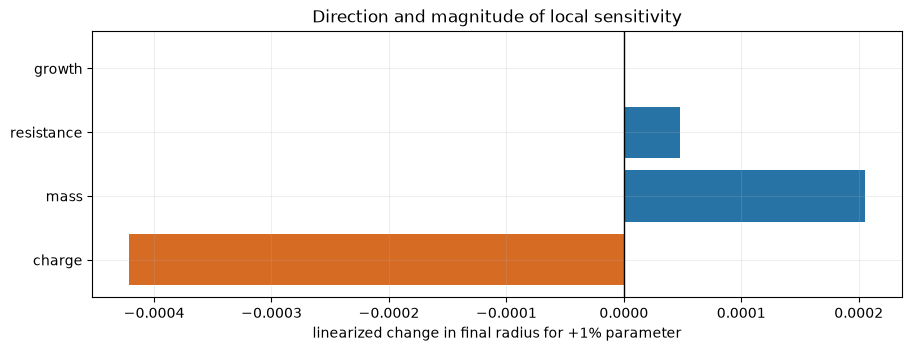

In [8]:
v_effect=.01*theta0.detach().numpy()[0]*grad.detach().numpy()[0]
v_fig,v_ax=plt.subplots(figsize=(9,3.4),layout='constrained')
v_ax.barh(PARAM_NAMES,v_effect,color=['#2873a6' if v_e>=0 else '#d66b24' for v_e in v_effect])
v_ax.axvline(0,color='black',lw=1); v_ax.set(xlabel='linearized change in final radius for +1% parameter',title='Direction and magnitude of local sensitivity')
plt.show()

## 5. Check time-step convergence
Compare final state at three resolutions. A small error between successive grids supports solver convergence over this interval. It does not justify longer runs through stagnation or make the perturbation law physical.

In [9]:
resolutions=[48,96,192]
ends=[simulate(theta0.detach(),replace(MachineConfig(),samples=n))[1][0,-1].numpy() for n in resolutions]
coarse=float(np.max(np.abs(ends[0]-ends[2]))); fine=float(np.max(np.abs(ends[1]-ends[2])))
print({'48_vs_192':coarse,'96_vs_192':fine})
assert fine<coarse

{'48_vs_192': 1.5133888697782538e-08, '96_vs_192': 8.443695811988228e-10}


## 6. Account for energy
For this circuit and mean-motion model,
$$E=CV^2/2+LI^2/2+mu^2/2,\qquad \dot E=-RI^2-du^2.$$
The thermal proxy is omitted from this mechanical/electrical balance because the Joule term is counted as a loss here. The passive perturbation variable carries no modeled energy. Do not add its growth to an energy budget without changing the equations.

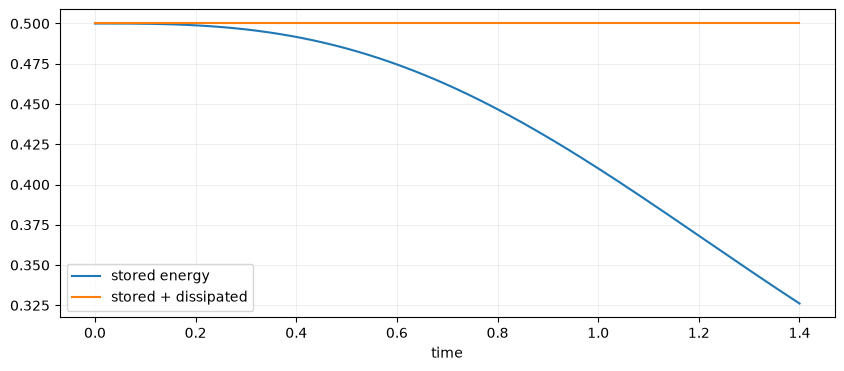

Maximum balance residual: 1.2365166583983012e-06
/Users/operator/Desktop/Factor/runs/world-model/06-810ea1c4aa


In [10]:
cfg=MachineConfig(); td,sd=simulate(theta0.detach(),replace(cfg,samples=192)); v,i,r,u,heat,a=sd[0].T
L=cfg.inductance+cfg.coupling*torch.log(1/r)
energy=.5*cfg.capacitance*v*v+.5*L*i*i+.5*theta0.detach()[0,1]*u*u
loss=theta0.detach()[0,2]*i*i+cfg.damping*u*u
integral=torch.cat([torch.zeros(1,dtype=td.dtype),torch.cumsum(.5*(loss[1:]+loss[:-1])*torch.diff(td),0)])
balance=energy+integral
balance_error=float((balance-balance[0]).abs().max())
plt.plot(td,energy,label='stored energy'); plt.plot(td,balance,label='stored + dissipated'); plt.legend(); plt.xlabel('time'); plt.show()
print('Maximum balance residual:',balance_error)
assert balance_error<1e-4
run=save_run(ROOT,'06',{'gradient_error':error,'grid_error':fine,'energy_residual':balance_error},asdict(cfg))
print(run)

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Remove the motional-inductance term in a copied RHS and observe the energy residual.
2. Differentiate final perturbation amplitude and compare sensitivity to charge and growth.
3. Add an explicit applied pulse or second circuit section, document its units, and repeat convergence and balance checks.